Shape: (286, 10)
     age menopause tumor-size inv-nodes node-caps  deg-malig breast  \
0  30-39   premeno      30-34       0-2        no          3   left   
1  40-49   premeno      20-24       0-2        no          2  right   
2  40-49   premeno      20-24       0-2        no          2   left   
3  60-69      ge40      15-19       0-2        no          2  right   
4  40-49   premeno        0-4       0-2        no          2  right   

  breast-quad irradiat  target  
0    left_low       no       0  
1    right_up       no       0  
2    left_low       no       0  
3     left_up       no       0  
4   right_low       no       0  

Missing values:
 age            0
menopause      0
tumor-size     0
inv-nodes      0
node-caps      8
deg-malig      0
breast         0
breast-quad    1
irradiat       0
target         0
dtype: int64


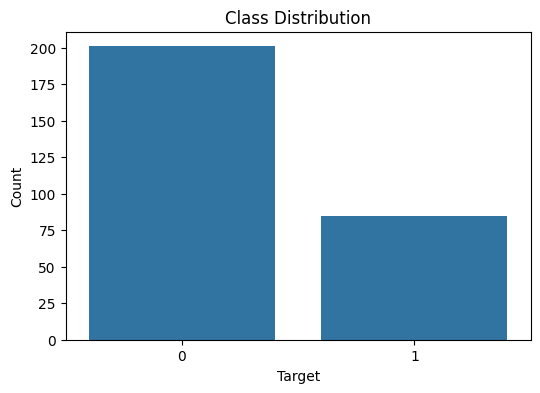


Accuracy: 0.7413793103448276
Precision: 0.5833333333333334
Recall: 0.4117647058823529
F1 Score: 0.4827586206896552

Confusion Matrix:
 [[36  5]
 [10  7]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.88      0.83        41
           1       0.58      0.41      0.48        17

    accuracy                           0.74        58
   macro avg       0.68      0.64      0.66        58
weighted avg       0.72      0.74      0.73        58



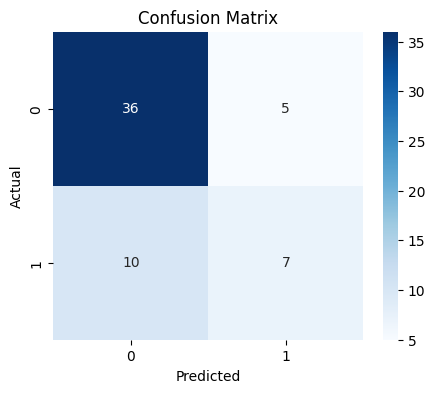

In [14]:
# =========================================
# Minor Project 1
# Breast Cancer Diagnosis Prediction
# UCI Breast Cancer Dataset
# Random Forest
# =========================================

!pip -q install ucimlrepo

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Load dataset
dataset = fetch_ucirepo(id=14)

X = dataset.data.features.copy()
y = dataset.data.targets.copy()

if isinstance(y, pd.DataFrame):
    y = y.iloc[:, 0]
else:
    y = pd.Series(y)

# Combine
df = X.copy()
df["target"] = y.values

# Convert target to binary
df["target"] = df["target"].map({
    "no-recurrence-events": 0,
    "recurrence-events": 1
})

# Drop rows where target mapping failed
df = df.dropna(subset=["target"])
df["target"] = df["target"].astype(int)

# Basic info
print("Shape:", df.shape)
print(df.head())
print("\nMissing values:\n", df.isnull().sum())

# Class distribution
plt.figure(figsize=(6,4))
sns.countplot(x=df["target"])
plt.title("Class Distribution")
plt.xlabel("Target")
plt.ylabel("Count")
plt.show()

# Separate X and y
X = df.drop(columns=["target"])
y = df["target"]

# Identify column types
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numeric_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

# Preprocessing
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Model pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=300,
        random_state=42
    ))
])

# Train
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Evaluate
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
cm = confusion_matrix(y_test, y_pred)

print("\nAccuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)
print("F1 Score:", f1)
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", classification_report(y_test, y_pred, zero_division=0))

# Plot confusion matrix
plt.figure(figsize=(5,4))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=["0", "1"],
    yticklabels=["0", "1"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()